In [1]:
include("PermBasis.jl")
include("PlotSetup.jl")
include("MonteCarloMF.jl")
using PyPlot
using DifferentialEquations
using JLD2

legend_kwargs = (
    fontsize=12,
    framealpha=0.9,
    borderpad=0.3,
    labelspacing=0.3,
    handlelength=2.0
)


(fontsize = 12, framealpha = 0.9, borderpad = 0.3, labelspacing = 0.3, handlelength = 2.0)

In [2]:
struct NullAxis end

function Base.getproperty(::NullAxis, name::Symbol)
    return (args...; kwargs...) -> nothing
end

stub = NullAxis()

NullAxis()

In [ ]:
function plot_mf_sweep!(ax;
    N = 10^8,
    rs = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1],
    cmap_name = "turbo"
)
    cmap = get_cmap(cmap_name)
    norm = matplotlib.colors.Normalize(vmin=minimum(rs), vmax=maximum(rs))

    tmax = 2000.0 * log(N) / N

    for r in rs
        params = Dict(
            "global_decay" => 1.0,
            "global_pump" => 0.0,
            "local_pump" => 0.0,
            "local_dephasing" => r * N,
            "local_decay" => 0.0 * N,
        )

        p = [params["global_decay"], params["local_dephasing"], N, params["local_decay"]]
        u0 = [1 / N, 1 / 2]
        prob = ODEProblem(meanfield_reduced!, u0, (0.0, tmax), p)

        ts = exp.(range(log(1e-12), log(tmax), length=100000))

        mfsol = solve(
            prob,
            AutoTsit5(Rosenbrock23()),
            reltol=1e-15,
            abstol=1e-15,
            saveat=ts
        )

        color = cmap(norm(r))

        ax.plot(
            mfsol.t / log(N) * N,
            4 * element(mfsol, 1);
            color=color,
            linestyle="solid",
            linewidth=2.0,
            label=L"g_\xi = %$r"
        )

        Intens = 4 * element(mfsol, 1)
        tau = mfsol.t / log(N) * N

        idx = argmax(Intens)
        ax.plot(tau[idx], Intens[idx];
            marker="*",
            markersize=10,
            color=color,
            linestyle="none"
        )
    end

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_ylim(bottom=4e-10, top = 2)
    ax.set_xlim(left = 1e-2)
    ax.set_xlabel(L"t\Gamma N/\log N")
    ax.set_ylabel(L"I_{\star}/I_\star^{\rm{(Dicke)}}")

    ticks = [1.0, 1/sqrt(N), 4/N]
    ax.set_yticks(ticks)
    ax.set_yticklabels([L"1", L"\tfrac{1}{\sqrt{N}}", L"\tfrac{4}{N}"])
    

    return ax
end

function plot_mf_trajectories_SM!(ax;
    N = 10^8,
    rs = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1],
    cmap_name = "turbo",
    triangle_alpha = 0.12
)
    cmap = get_cmap(cmap_name)
    norm = matplotlib.colors.Normalize(vmin=minimum(rs), vmax=maximum(rs))

    # Dicke triangle:
    # 0 <= S/N <= 1/2
    # -S/N <= M/N <= S/N
    sgrid = range(0.0, 0.5, length=400)


    # Boundary lines of the allowed region
    ax.plot(sgrid, sgrid; color="black", linestyle="--", linewidth=0.8, alpha=0.7)
    ax.plot(sgrid, .-sgrid; color="black", linestyle="--", linewidth=0.8, alpha=0.7)
    ax.plot([0.0, 0.5], [0.0, 0.0]; color="black", linestyle=":", linewidth=0.8, alpha=0.5)

    tmax = 2000.0 * log(N) / N

    for r in rs
        params = Dict(
            "global_decay" => 1.0,
            "global_pump" => 0.0,
            "local_pump" => 0.0,
            "local_dephasing" => r * N,
            "local_decay" => 0.0 * N,
        )

        p = [params["global_decay"], params["local_dephasing"], N, params["local_decay"]]
        u0 = [1 / N, 1 / 2]
        prob = ODEProblem(meanfield_reduced!, u0, (0.0, tmax), p)

        ts = exp.(range(log(1e-12), log(tmax), length=100000))

        mfsol = solve(
            prob,
            AutoTsit5(Rosenbrock23()),
            reltol=1e-15,
            abstol=1e-15,
            saveat=ts
        )

        # Convention assumed:
        # u[1] = I / N^2 = (S/N)^2 - (M/N)^2
        # u[2] = M / N
        Inorm = element(mfsol, 1)
        Mnorm = element(mfsol, 2)
        Snorm = sqrt.(max.(Inorm .+ Mnorm.^2, 0.0))

        color = cmap(norm(r))

        ax.plot(
            Snorm,
            Mnorm;
            color=color,
            linestyle="solid",
            linewidth=2.0,
            label=L"g_\xi = %$r"
        )

        i = argmin(abs.(Mnorm .- 0.2))
        if i == length(Mnorm) continue end

        ax.annotate(
            "",
            xy=(Snorm[i+1], Mnorm[i+1]),
            xytext=(Snorm[i-1], Mnorm[i-1]),
            arrowprops=Dict(
                "arrowstyle" => "->",
                "color" => color,
                "lw" => 2.0
            )
        )
    end

    sgrid = range(0.0, 0.52, length=400)

    ymax = 0.52
    ymin = -0.52

    # Forbidden regions
    ax.fill_between(sgrid, sgrid, ymax; color="gray", alpha=triangle_alpha, linewidth=0)
    ax.fill_between(sgrid, ymin, .-sgrid; color="gray", alpha=triangle_alpha, linewidth=0)
    # Entire strip x > 0.5 is forbidden
    ax.axvspan(0.5, 0.52; color="gray", alpha=triangle_alpha, linewidth=0)

    ax.set_xlim(0.0, 0.52)
    ax.set_ylim(-0.52, 0.52)
    ax.set_xlabel(L"S/N")
    ax.set_ylabel(L"M/N")

    ax.set_xticks([0.0, 0.5])
    ax.set_yticks([-0.5, 0.0, 0.5])

    ax.set_xticklabels([L"0", L"\tfrac12"])
    ax.set_yticklabels([L"-\tfrac12", L"0", L"\tfrac12"])
    
    return ax
end

function plot_peak_observables!(ax1, ax2;
    N = 10^8,
    rs_mark = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1],
    cmap_name = "turbo"
)
    rs = sort(unique(vcat(range(0.0, 1.2, length=200)..., rs_mark...)))

    cmap = get_cmap(cmap_name)
    norm = matplotlib.colors.Normalize(vmin=minimum(rs), vmax=maximum(rs))

    tmax = 2000.0 * log(N) / N

    tpeaks = Float64[]
    Ipeaks = Float64[]

    for r in rs
        params = Dict(
            "global_decay" => 1.0,
            "global_pump" => 0.0,
            "local_pump" => 0.0,
            "local_dephasing" => r * N,
            "local_decay" => 0.0 * N,
        )

        p = [params["global_decay"], params["local_dephasing"], N, params["local_decay"]]
        u0 = [1 / N, 1 / 2]
        prob = ODEProblem(meanfield_reduced!, u0, (0.0, tmax), p)

        ts = range(0.0, tmax, length=100000)

        mfsol = solve(
            prob,
            AutoTsit5(Rosenbrock23()),
            reltol=1e-15,
            abstol=1e-15,
            saveat=ts
        )

        Ivals = 4 * element(mfsol, 1)
        imax = argmax(Ivals)

        push!(tpeaks, mfsol.t[imax] * N / log(N))
        push!(Ipeaks, Ivals[imax])
    end

    # --- Ipeaks ---
    ax1.plot(rs, Ipeaks, color="black", linewidth=1.5, label = L"(1-g_\xi)^2")

    for r in rs_mark
        idx = argmin(abs.(rs .- r))
        color = cmap(norm(r))
        ax1.plot(rs[idx], Ipeaks[idx];
            marker="*",
            markersize=10,
            color=color,
            linestyle="none"
        )
    end

    ax1.set_xlabel(L"\xi/(N\Gamma)")
    ax1.set_ylabel(L"I_{\star}/I_\star^{\rm{(Dicke)}}")

    # --- tpeaks ---
    ax2.plot(rs, tpeaks, color="black", linewidth=1.5)

    for r in rs_mark
        idx = argmin(abs.(rs .- r))
        color = cmap(norm(r))
        ax2.plot(rs[idx], tpeaks[idx];
            marker="*",
            markersize=10,
            color=color,
            linestyle="none"
        )
    end

    ax2.set_xlabel(L"\xi/(N\Gamma)")
    ax2.set_ylabel(L"N t_\star / \log N")
    ax2.set_ylim(top=10.0, bottom=-0.2)

    return ax1, ax2
end

function plot_mf_sweep_gamma!(ax;
    N = 10^8,
    gbar_vals = [0.0, 0.02, 0.04, 0.06, 0.08, 0.1],
    cmap_name = "turbo",
    c = 2000.0,
    d = 1e-12
)
    cmap = get_cmap(cmap_name)
    norm = matplotlib.colors.Normalize(vmin=minimum(gbar_vals), vmax=maximum(gbar_vals))

    tmax = c * log(N) / N

    for gbar in gbar_vals
        γ = gbar * N / log(N)

        params = Dict(
            "global_decay" => 1.0,
            "global_pump" => 0.0,
            "local_pump" => 0.0,
            "local_dephasing" => 0.0,
            "local_decay" => γ,
        )

        p = [params["global_decay"], params["local_dephasing"], N, params["local_decay"]]
        u0 = [1 / N, 1 / 2]
        prob = ODEProblem(meanfield_reduced!, u0, (0.0, tmax), p)

        ts = exp.(range(log(d), log(tmax), length=100000))

        mfsol = solve(
            prob,
            AutoTsit5(Rosenbrock23()),
            reltol=1e-15,
            abstol=1e-15,
            saveat=ts
        )

        color = cmap(norm(gbar))

        ax.plot(
            mfsol.t / log(N) * N,
            4 * element(mfsol, 1);
            color=color,
            linewidth=2.0,
            linestyle = "solid",
            label=L"\bar g_\gamma = %$gbar"
        )

        Intens = 4 * element(mfsol, 1)
        tau = mfsol.t / log(N) * N

        idx = argmax(Intens)
        ax.plot(tau[idx], Intens[idx];
            marker="*",
            markersize=10,
            color=color,
            linestyle="none"
        )
    end

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_ylim(bottom=1e-10, top = 2)
    ax.set_xlim(left = 1e-2)
    ax.set_xlabel(L"t\Gamma N/\log N")
    ax.set_ylabel(L"I_{\star}/I_\star^{\rm{(Dicke)}}")

    ticks = [1.0, 1/sqrt(N), 4/N]
    ax.set_yticks(ticks)
    ax.set_yticklabels([L"1", L"\tfrac{1}{\sqrt{N}}", L"\tfrac{4}{N}"])

    return ax
end

function plot_mf_trajectories_SM_gamma!(ax;
    N = 10^8,
    gbar_vals = [0.0, 0.02, 0.04, 0.06, 0.08, 0.1],
    cmap_name = "turbo",
    triangle_alpha = 0.12,
    c = 2000.0,
    d = 1e-12,
    r = 0.0
)
    cmap = get_cmap(cmap_name)
    norm = matplotlib.colors.Normalize(vmin=minimum(gbar_vals), vmax=maximum(gbar_vals))

    sgrid = range(0.0, 0.5, length=400)

    ax.plot(sgrid, sgrid; color="black", linestyle="--", linewidth=0.8, alpha=0.7)
    ax.plot(sgrid, .-sgrid; color="black", linestyle="--", linewidth=0.8, alpha=0.7)
    ax.plot([0.0, 0.5], [0.0, 0.0]; color="black", linestyle=":", linewidth=0.8, alpha=0.5)

    tmax = c * log(N) / N

    for gbar in gbar_vals
        γ = gbar * N / log(N)

        params = Dict(
            "global_decay" => 1.0,
            "global_pump" => 0.0,
            "local_pump" => 0.0,
            "local_dephasing" => r * N,
            "local_decay" => γ,
        )

        p = [params["global_decay"], params["local_dephasing"], N, params["local_decay"]]
        u0 = [log(1 / N), 1 / 2]
        prob = ODEProblem(meanfield_log_transformed!, u0, (0.0, tmax), p)

        ts = exp.(range(log(d), log(tmax), length=100000))

        mfsol = solve(
            prob,
            AutoTsit5(Rosenbrock23()),
            reltol=1e-15,
            abstol=1e-15,
            saveat=ts
        )

        Inorm = exp.(element(mfsol, 1))
        Mnorm = element(mfsol, 2)
        Snorm = sqrt.(max.(Inorm .+ Mnorm.^2, 0.0))

        color = cmap(norm(gbar))

        ax.plot(
            Snorm,
            Mnorm;
            color=color,
            linewidth=2.0,
            linestyle="solid",
            label=L"\bar g_\gamma = %$gbar"
        )

        i = argmin(abs.(Mnorm .+ 0.1))

        ax.annotate(
            "",
            xy=(Snorm[i+1], Mnorm[i+1]),
            xytext=(Snorm[i-1], Mnorm[i-1]),
            arrowprops=Dict(
                "arrowstyle" => "->",
                "color" => color,
                "lw" => 2.0
            )
        )
    end

    sgrid = range(0.0, 0.52, length=400)
    ymax = 0.52

    ax.fill_between(sgrid, sgrid, ymax; color="gray", alpha=triangle_alpha, linewidth=0)
    ax.fill_between(sgrid, -ymax, .-sgrid; color="gray", alpha=triangle_alpha, linewidth=0)
    ax.axvspan(0.5, 0.52; color="gray", alpha=triangle_alpha, linewidth=0)

    ax.set_xlim(0.0, 0.52)
    ax.set_ylim(-0.52, 0.52)
    ax.set_xlabel(L"S/N")
    ax.set_ylabel(L"M/N")

        
    ax.set_xticks([0.0, 0.5])
    ax.set_yticks([-0.5, 0.0, 0.5])

    ax.set_xticklabels([L"0", L"\tfrac12"])
    ax.set_yticklabels([L"-\tfrac12", L"0", L"\tfrac12"])

    return ax
end


function plot_peak_observables_gamma!(ax1, ax2;
    N = 10^8,
    gbar_mark = [0.0, 0.02, 0.04, 0.06, 0.08, 0.1],
    cmap_name = "turbo",
    c = 2000.0,
    N_asymptotic = nothing,
    gbar_asymptotic = nothing,
    asymptotic_color = "black",
    asymptotic_linestyle = "--",
    asymptotic_linewidth = 1.2
)
    cmap = get_cmap(cmap_name)

    function compute_peak_curves(Nloc, gbar_vals)
        tmax = Float64(c * log(Nloc) / Nloc)

        tpeaks = Float64[]
        Ipeaks = Float64[]

        for gbar in gbar_vals
            γ = Float64(gbar * Nloc / log(Nloc))

            params = Dict(
                "global_decay" => 1.0,
                "global_pump" => 0.0,
                "local_pump" => 0.0,
                "local_dephasing" => 0.0,
                "local_decay" => γ,
            )

            p = [params["global_decay"], params["local_dephasing"], Nloc, params["local_decay"]]
            u0 = [Float64(log(1 / Nloc)), 1 / 2]
            prob = ODEProblem(meanfield_log_transformed!, u0, (0.0, tmax), p)

            ts = range(0.0, tmax, length=100000)

            mfsol = solve(
                prob,
                AutoTsit5(Rosenbrock23()),
                reltol=1e-15,
                abstol=1e-15,
                saveat=ts
            )

            Ivals = 4 * exp.(element(mfsol, 1))
            imax = argmax(Ivals)

            push!(tpeaks, mfsol.t[imax] * Float64(Nloc / log(Nloc)))
            push!(Ipeaks, Ivals[imax])
        end

        return Ipeaks, tpeaks
    end

    # marked / finite-N curve
    gbar_vals = sort(unique(vcat(range(0.0, maximum(gbar_mark), length=200)..., gbar_mark...)))
    norm = matplotlib.colors.Normalize(vmin=minimum(gbar_vals), vmax=maximum(gbar_vals))

    Ipeaks, tpeaks = compute_peak_curves(N, gbar_vals)

    ax1.plot(gbar_vals, Ipeaks;
        color="black", linewidth=1.5, linestyle="solid", label = L"N=10^8"
    )
    ax2.plot(gbar_vals, tpeaks;
        color="black", linewidth=1.5, linestyle="solid", label = L"N=10^8"
    )

    for gbar in gbar_mark
        idx = argmin(abs.(gbar_vals .- gbar))
        color = cmap(norm(gbar))

        ax1.plot(gbar_vals[idx], Ipeaks[idx];
            marker="*",
            markersize=10,
            color=color,
            linestyle="none"
        )
        ax2.plot(gbar_vals[idx], tpeaks[idx];
            marker="*",
            markersize=10,
            color=color,
            linestyle="none"
        )
    end

    function beta_asymptotic(gbar; gξ = 0.0)
        A = 1 - gξ - (1 + gξ) * log(2 / (1 + gξ))
        return max(0.0, 1 - A / gbar)
    end
    # inset: finite-N scaling exponent beta_N
    inset = ax1.inset_axes([0.52, 0.48, 0.43, 0.43])  # [x0, y0, width, height]

    βvals = -log.(Ipeaks) ./ log(N)

    # avoid gbar = 0 in asymptotic expression
    gbar_dense = collect(range(
        maximum([minimum(gbar_vals[gbar_vals .> 0]), 1e-8]),
        maximum(gbar_vals),
        length=400
    ))

    βasym = [beta_asymptotic(gbar) for gbar in gbar_dense]

    inset.plot(gbar_vals, βvals;
        color="black",
        linewidth=1.2,
        linestyle="solid"
    )

    inset.plot(gbar_dense, βasym;
        color="gray",
        linewidth=1.0,
        linestyle="--"
    )

    inset.set_xlabel(L"\bar g_\gamma", fontsize=8)
    inset.set_ylabel(L"\beta(g_\zeta,\bar g_\xi)", fontsize=8)

    inset.tick_params(axis="both", labelsize=7)
    #inset.set_ylim(bottom=-0.05, top=1.05)
    inset.set_xlim(left=0.0, right=maximum(gbar_vals))

    # optional asymptotic curve
    if N_asymptotic !== nothing
        gbar_asymptotic === nothing && (gbar_asymptotic = range(0.0, maximum(gbar_mark), length=400))
        Ipeaks_asym, tpeaks_asym = compute_peak_curves(N_asymptotic, collect(gbar_asymptotic))

        ax1.plot(gbar_asymptotic, Ipeaks_asym;
            color=asymptotic_color,
            linewidth=asymptotic_linewidth,
            linestyle=asymptotic_linestyle,
            label = L"N\to\infty"
        )
        ax2.plot(gbar_asymptotic, tpeaks_asym;
            color=asymptotic_color,
            linewidth=asymptotic_linewidth,
            linestyle=asymptotic_linestyle,
            label = L"N\to\infty"
        )
    end

    ax1.set_xlabel(L"\gamma\log N/(N\Gamma)")
    ax1.set_ylabel(L"I_{\star}/I_\star^{\rm{(Dicke)}}")
    ax1.legend(;legend_kwargs..., loc = "lower left")

    ax2.set_xlabel(L"\gamma\log N/(N\Gamma)")
    ax2.set_ylabel(L"N t_\star / \log N")
    ax2.legend(;legend_kwargs...)
    return ax1, ax2
end

plot_peak_observables_gamma! (generic function with 1 method)

In [4]:
function plot_mf_trajectories_SM_gamma!(ax;
    N = 10^8,
    gbar_vals = [0.0, 0.02, 0.04, 0.06, 0.08, 0.1],
    cmap_name = "turbo",
    triangle_alpha = 0.12,
    c = 2000.0,
    d = 1e-12,
    r = 0.0,
)
    I_leave = 200000 / N
    cmap = get_cmap(cmap_name)
    norm = matplotlib.colors.Normalize(vmin=minimum(gbar_vals), vmax=maximum(gbar_vals))

    sgrid = range(0.0, 0.5, length=400)

    ax.plot(sgrid, sgrid; color="black", linestyle="--", linewidth=0.8, alpha=0.7)
    ax.plot(sgrid, .-sgrid; color="black", linestyle="--", linewidth=0.8, alpha=0.7)
    ax.plot([0.0, 0.5], [0.0, 0.0]; color="black", linestyle=":", linewidth=0.8, alpha=0.5)

    tmax = c * log(N) / N

    for gbar in gbar_vals
        γ = gbar * N / log(N)

        params = Dict(
            "global_decay" => 1.0,
            "global_pump" => 0.0,
            "local_pump" => 0.0,
            "local_dephasing" => r * N,
            "local_decay" => γ,
        )

        p = [
            params["global_decay"],
            params["local_dephasing"],
            N,
            params["local_decay"],
        ]

        u0 = [log(1 / N), 1 / 2]
        prob = ODEProblem(meanfield_log_transformed!, u0, (0.0, tmax), p)

        ts = exp.(range(log(d), log(tmax), length=100000))

        mfsol = solve(
            prob,
            AutoTsit5(Rosenbrock23()),
            reltol=1e-15,
            abstol=1e-15,
            saveat=ts,
        )

        Inorm = exp.(element(mfsol, 1))
        Mnorm = element(mfsol, 2)
        Snorm = sqrt.(max.(Inorm .+ Mnorm.^2, 0.0))

        color = cmap(norm(gbar))

        ax.plot(
            Snorm,
            Mnorm;
            color=color,
            linewidth=2.0,
            linestyle="solid",
            label=L"\bar g_\gamma = %$gbar",
        )

        # Mark first crossing of the intensity threshold I_leave.
        ileave = nothing
        for k in 2:length(Inorm)
            if Inorm[k - 1] <= I_leave && Inorm[k] > I_leave
                ileave = k
                break
            end
        end

    if ileave !== nothing
        x0 = Snorm[ileave]
        y0 = Mnorm[ileave]

        # --- compute local direction (robust centered difference) ---
        step = 100000 ÷ 50
        if 2 ≤ ileave ≤ length(Snorm) - 1
            dx = Snorm[ileave + step] - Snorm[ileave - step]
            dy = Mnorm[ileave + step] - Mnorm[ileave - step]
        else
            dx = Snorm[min(ileave + step, end)] - Snorm[max(ileave - step, 1)]
            dy = Mnorm[min(ileave + step, end)] - Mnorm[max(ileave - step, 1)]
        end

        # normalize direction (avoid scale issues)
        normdir = sqrt(dx^2 + dy^2) + 1e-16
        dx /= normdir
        dy /= normdir

        # choose a small visual length (relative to triangle scale ~1)
        ℓ = 0.1

        # --- draw arrow ---
        ax.annotate(
            "",
            xy=(x0 + ℓ * dx, y0 + ℓ * dy),
            xytext=(x0, y0),
            arrowprops=Dict(
                "arrowstyle" => "->",
                "color" => color,
                "lw" => 2.0,
            ),
            zorder=11,
        )

        # optional: keep the marker
        ax.scatter(
            [x0],
            [y0];
            s=40,
            color=color,
            edgecolors="black",
            linewidths=0.7,
            zorder=12,
        )
    end

        i = argmin(abs.(Mnorm .+ 0.1))

        if 1 < i < length(Mnorm)
            ax.annotate(
                "",
                xy=(Snorm[i + 1], Mnorm[i + 1]),
                xytext=(Snorm[i - 1], Mnorm[i - 1]),
                arrowprops=Dict(
                    "arrowstyle" => "->",
                    "color" => color,
                    "lw" => 2.0,
                ),
            )
        end
    end

    sgrid = range(0.0, 0.52, length=400)
    ymax = 0.52

    ax.fill_between(sgrid, sgrid, ymax; color="gray", alpha=triangle_alpha, linewidth=0)
    ax.fill_between(sgrid, -ymax, .-sgrid; color="gray", alpha=triangle_alpha, linewidth=0)
    ax.axvspan(0.5, 0.52; color="gray", alpha=triangle_alpha, linewidth=0)

    ax.set_xlim(0.0, 0.52)
    ax.set_ylim(-0.52, 0.52)
    ax.set_xlabel(L"S/N")
    ax.set_ylabel(L"M/N")

    ax.set_xticks([0.0, 0.5])
    ax.set_yticks([-0.5, 0.0, 0.5])

    ax.set_xticklabels([L"0", L"\tfrac12"])
    ax.set_yticklabels([L"-\tfrac12", L"0", L"\tfrac12"])

    return ax
end

plot_mf_trajectories_SM_gamma! (generic function with 1 method)

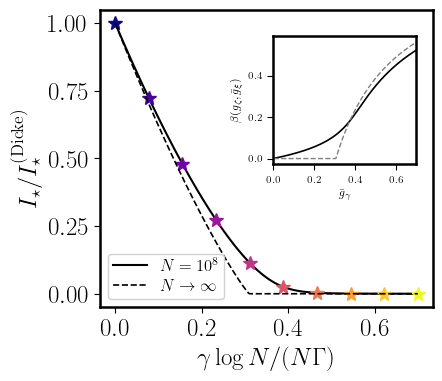

(PyObject <Axes: xlabel='$\\gamma\\log N/(N\\Gamma)$', ylabel='$I_{\\star}/I_\\star^{\\rm{(Dicke)}}$'>, NullAxis())

In [40]:
fig, ax = subplots()
plot_peak_observables_gamma!(ax, stub; gbar_mark=gbar_mark, c=c, N = N, N_asymptotic = Nas, cmap_name = cmap_name)

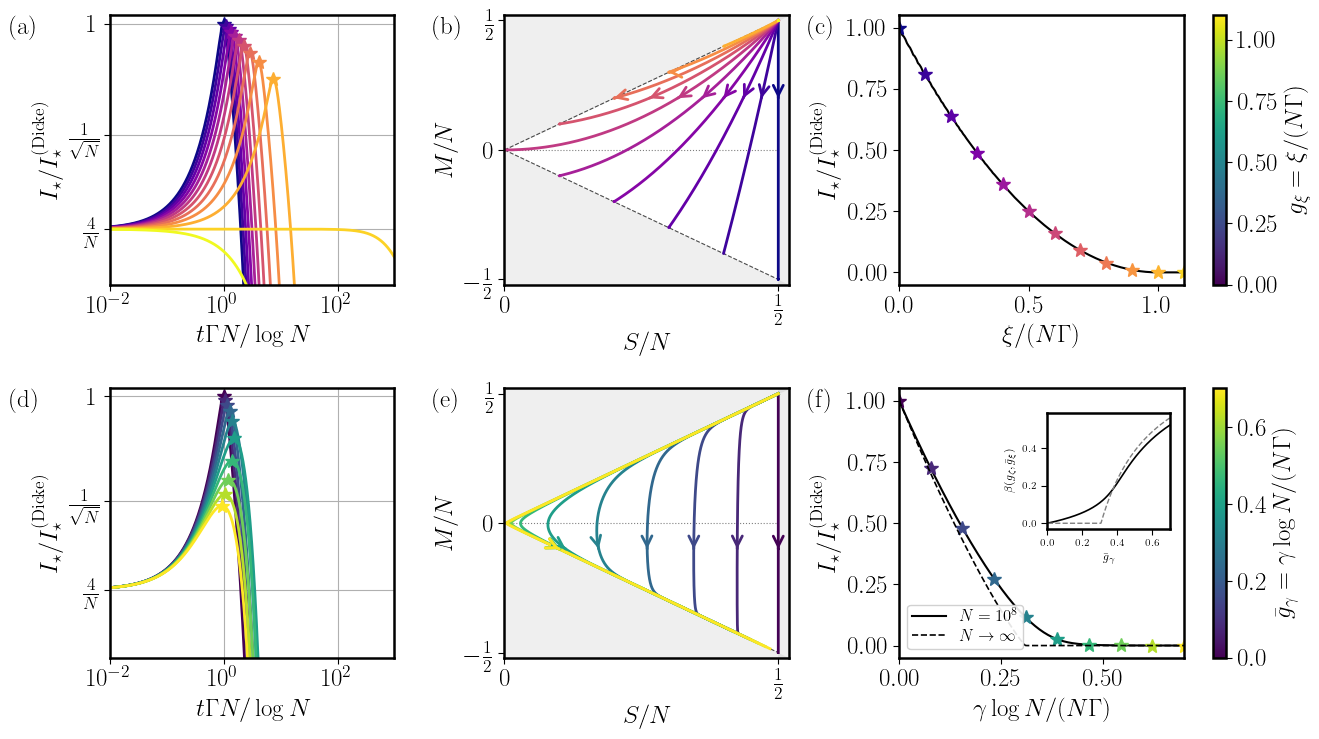

In [ ]:
N = 10^8
Nas = BigFloat(10)^300
# --- explicit parameter arrays ---
gbar_vals = range(0.0, 0.7, 10)
gbar_mark = gbar_vals
c = 6.0
d = 1e-12

cmap_name = "plasma"
w, h = latex_plot_setup(ratio=0.9, scale=1.8)
fig, axes = subplots(ncols = 3, nrows = 2, figsize = (3 * w, 2 * h))
stub = NullAxis()

plot_mf_sweep!(axes[1,1]; N = N, cmap_name = cmap_name)
plot_mf_trajectories_SM!(axes[1,2]; N = N, cmap_name = cmap_name)
plot_peak_observables!(axes[1,3], stub; N = N, cmap_name = cmap_name)

cmap_name = "viridis"
plot_mf_sweep_gamma!(axes[2,1]; gbar_vals=gbar_vals, c=c, d=d, N = N, cmap_name = cmap_name)
plot_mf_trajectories_SM_gamma!(axes[2,2]; gbar_vals=gbar_vals, c=c, d=d, N = N, cmap_name = cmap_name)
plot_peak_observables_gamma!(axes[2,3], stub; gbar_mark=gbar_mark, c=c, N = N, N_asymptotic = Nas, cmap_name = cmap_name)

axes[1,1].grid()
axes[2,1].grid()
#axes[1,1].axhline(4.0/N, color = "k", linestyle = "dashed", alpha = 0.5)
#axes[1,1].axhline(1.0, color = "k", linestyle = "dashed", alpha = 0.5)
#axes[2,1].axhline(4.0/N, color = "k", linestyle = "dashed", alpha = 0.5)
#axes[2,1].axhline(1.0, color = "k", linestyle = "dashed", alpha = 0.5)

axes[1,1].text(-0.35, 1.0, "(a)", transform=axes[1,1].transAxes, va="top")
axes[1,2].text(-0.25, 1.0, "(b)", transform=axes[1,2].transAxes, va="top")
axes[1,3].text(-0.32, 1.0, "(c)", transform=axes[1,3].transAxes, va="top")
axes[2,1].text(-0.35, 1.0, "(d)", transform=axes[2,1].transAxes, va="top")
axes[2,2].text(-0.25, 1.0, "(e)", transform=axes[2,2].transAxes, va="top")
axes[2,3].text(-0.32, 1.0, "(f)", transform=axes[2,3].transAxes, va="top")
axes[1,1].set_xlim(left = 1e-2, right = 1e3)
axes[2,1].set_xlim(left = 1e-2, right = 1e3)

axes[1,3].set_xlim(left = 0.0, right = 1.1)
axes[2,3].set_xlim(left = 0.0, right = 0.7)


plt = pyimport("matplotlib.pyplot")
mpl = pyimport("matplotlib")

# after all plotting, before savefig

# leave room on the right for row colorbars
fig.subplots_adjust(right = 0.88, wspace = 0.35, hspace = 0.35)
fig.tight_layout()

# --- top row colorbar: dephasing ---
cmap_name = "plasma"
cmap = plt.get_cmap(cmap_name)
norm_top = mpl.colors.Normalize(vmin = 0.0, vmax = 1.1)  # or your actual g_xi range
sm_top = mpl.cm.ScalarMappable(norm = norm_top, cmap = cmap)
sm_top.set_array([])

cb_top = fig.colorbar(
    sm_top,
    ax = axes[1, :],
    location = "right",
    fraction = 0.035,
    pad = 0.025,
)
cb_top.set_label(L"$g_\xi=\xi/(N\Gamma)$")

# --- bottom row colorbar: spontaneous emission ---
cmap_name = "viridis"
norm_bot = mpl.colors.Normalize(vmin = minimum(gbar_vals), vmax = maximum(gbar_vals))
sm_bot = mpl.cm.ScalarMappable(norm = norm_bot, cmap = cmap)
sm_bot.set_array([])

cb_bot = fig.colorbar(
    sm_bot,
    ax = axes[2, :],
    location = "right",
    fraction = 0.035,
    pad = 0.025,
)
cb_bot.set_label(L"$\bar g_\gamma=\gamma\log N/(N\Gamma)$")

savefig("../data/fig2.pdf", bbox_inches = "tight")
